# **Mount my Drive**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).




---



# **Script Start**

In [ ]:
import numpy as np
import json
import os
import csv #[Hyosun]
import pandas as pd #[Hyosun]
import random       #[Hyosun]

# [Hyosun] confusion matrix
import seaborn as sn
import pandas as pd
import matplotlib.pyplot as plt
# [/Hyosun] confusion matrix

In [ ]:
def get_immediate_files(a_dir):
    return [name for name in os.listdir(a_dir) if os.path.isfile(os.path.join(a_dir, name))]

# **IurbanEvent**

In [ ]:
# dataset downloaded from https://zenodo.org/records/1213793
# please change it to your IurbanEvent dataset path
# [Hyosun] current path: ./src/prep_data/IurbanEvent [/Hyosun]
event_path = './data/event_04s/'
#[Hyosun] use 11 labels
labels_arr = [#'bell',
              'bird', #'broom', #'carhorn',
              'citycar', #'citystep',
              'construction', #'coughing',
              'dog', #'doorbell', 'doorcar', 'doorhouse',
              'plane', 'roadcar', 'siren',
              'step', #[Hyosun] combined into one folder "step" from 'stepcity' and 'steppark'
              'stopcar', #'storm', #'streetnoise', 'suitcase',
              'train', #'tram',
              'truck'] #, 'voice']


In [ ]:
cwd = os.getcwd()
print(cwd)

/content/drive/My Drive/hssast/src/finetune/Isolated_urbansound/exp/2023-12-20_iurbanevent/[success]13:32:18PM-test01-iurbanevent-comp_fusion-True-comp_fusion_method-use_all_patch-comp_fusion_multi_layer-[4,11]-pooling-max_max-comp_fusion_mlp4-loss-CE-f10-16-t10-16-b48-lr1e-4-ft_avgtok-base--SSAST-Base-Patch-400-1x-noiseTrue


In [ ]:
os.chdir('/content/drive/MyDrive/hssast/src/finetune')
print(os.getcwd())
cur_dir = os.getcwd()

/content/drive/MyDrive/hssast/src/finetune


In [ ]:
dataset_folder = '/Isolated_urbansound'

In [ ]:
result_dir = '2023-12-20_iurbanevent/[success]13:32:18PM-test01-iurbanevent-comp_fusion-True-comp_fusion_method-use_all_patch-comp_fusion_multi_layer-[4,11]-pooling-max_max-comp_fusion_mlp4-loss-CE-f10-16-t10-16-b48-lr1e-4-ft_avgtok-base--SSAST-Base-Patch-400-1x-noiseTrue'

In [ ]:
os.chdir(cur_dir+dataset_folder+'/exp/'+ result_dir+'/')

In [ ]:
cur_dir = os.getcwd()
print(cur_dir)

/content/drive/MyDrive/hssast/src/finetune/Isolated_urbansound/exp/2023-12-20_iurbanevent/[success]13:32:18PM-test01-iurbanevent-comp_fusion-True-comp_fusion_method-use_all_patch-comp_fusion_multi_layer-[4,11]-pooling-max_max-comp_fusion_mlp4-loss-CE-f10-16-t10-16-b48-lr1e-4-ft_avgtok-base--SSAST-Base-Patch-400-1x-noiseTrue


### **create the label description dictionary**

In [ ]:
# [Hyosun: create the label description dictionary]
if os.path.exists('./../../../data/event_04s_class_labels_indices.csv') == True:
    label_set = np.loadtxt('./../../../data/event_04s_class_labels_indices.csv', delimiter=',', dtype='str')
    label_map = {}
    for i in range(1, len(label_set)):
        print("[Hyosun] label_set[i][0]: ", label_set[i][0])
        print("[Hyosun] label_set[i][2]: ", label_set[i][2])
        label_map[(label_set[i][2])] = label_set[i][0]
    print(label_map)
    print("[Hyosun] create the label description dictionary: using event_04s_class_labels_indices.csv finished!!")
#[/Hyosun: create the label description dictionary]

[Hyosun] label_set[i][0]:  0
[Hyosun] label_set[i][2]:  bird
[Hyosun] label_set[i][0]:  1
[Hyosun] label_set[i][2]:  citycar
[Hyosun] label_set[i][0]:  2
[Hyosun] label_set[i][2]:  construction
[Hyosun] label_set[i][0]:  3
[Hyosun] label_set[i][2]:  dog
[Hyosun] label_set[i][0]:  4
[Hyosun] label_set[i][2]:  plane
[Hyosun] label_set[i][0]:  5
[Hyosun] label_set[i][2]:  roadcar
[Hyosun] label_set[i][0]:  6
[Hyosun] label_set[i][2]:  siren
[Hyosun] label_set[i][0]:  7
[Hyosun] label_set[i][2]:  step
[Hyosun] label_set[i][0]:  8
[Hyosun] label_set[i][2]:  stopcar
[Hyosun] label_set[i][0]:  9
[Hyosun] label_set[i][2]:  train
[Hyosun] label_set[i][0]:  10
[Hyosun] label_set[i][2]:  truck
{'bird': '0', 'citycar': '1', 'construction': '2', 'dog': '3', 'plane': '4', 'roadcar': '5', 'siren': '6', 'step': '7', 'stopcar': '8', 'train': '9', 'truck': '10'}
[Hyosun] create the label description dictionary: using event_04s_class_labels_indices.csv finished!!


### **Load target(test_labels)**

In [ ]:
# read target.csv vs predictions
if os.path.exists('./../../../data/evaluation_setup/fold1_test.csv') == True:

    # [Hyosun] load target, i.e., test_labels
    test_meta = np.loadtxt('./../../../data/evaluation_setup/fold1_test.csv', delimiter='\t', dtype='str', skiprows=1)
    print(np.shape(test_meta))
    test_labels = []
    for i in range(0, len(test_meta)):
        # print("test_meta[i][1]: ", test_meta[i][1])
        cur_label = label_map[test_meta[i][1]]
        test_labels.append(int(cur_label))

    print("[Hyosun] test_labels[500]: ", test_labels[500])
    print("[Hyosun] test_labels information load: finished!!")
    #[/Hyosun] load target, i.e., test_labels

(1184, 2)
[Hyosun] test_labels[500]:  4
[Hyosun] test_labels information load: finished!!


### **Load Predictions**

In [ ]:
import csv
if os.path.exists('./result.csv') == True:
    # [Hyosun] get the best_epoch
    results = np.loadtxt('./result.csv', delimiter=',', dtype='str')
    # rows = []
    # with open('./result.csv', 'r') as file:
    #     csvreader = csv.reader(file)
    #     for row in csvreader:
    #         rows.append(row[0])
    # print(rows)
    print("np.shape(results): ", np.shape(results))
    # print(results)
    print("results[:,0]: \n", results[:,0])
    print("results[:,0].shape: \n", results[:,0].shape)
    best_epoch_1 = np.argmax(results[:,0]) #[Hyosun] +1 needed for epoch count later & Only the first occurrence is returned.
    print("best_epoch_1: ", best_epoch_1)
    print("\n")

    # [Hyosun] load predictions
    pred_dir = cur_dir+'/fold1/predictions/predictions_'+str(best_epoch_1+1)+'.csv' #[Hyosun] +1 needed for epoch count
    if os.path.exists(pred_dir) == True:
        pred = np.loadtxt(pred_dir, delimiter=',', dtype='str')
        print("pred.shape[0]: ", pred.shape[0])
        print("pred.shape: ", pred.shape)
        pred_labels = []
        for i in range(0, pred.shape[0]):
            pred_label = np.argmax(pred[i])
            # print("test_meta[i][1]: ", test_meta[i][1])
            pred_labels.append(pred_label)
        print("size of pred_labels: ", np.size(pred_labels))
        print("pred_labels[700:799]: ", pred_labels[700:799])

np.shape(results):  (45, 10)
results[:,0]: 
 ['7.069256756756756577e-01' '8.403716216216216006e-01'
 '8.429054054054053724e-01' '8.758445945945946276e-01'
 '8.707770270270269730e-01' '8.699324324324324564e-01'
 '8.775337837837837718e-01' '8.978040540540540571e-01'
 '8.885135135135134865e-01' '8.859797297297297147e-01'
 '9.045608108108108558e-01' '8.910472972972972583e-01'
 '8.994932432432432012e-01' '9.054054054054053724e-01'
 '8.944256756756756577e-01' '9.011824324324324564e-01'
 '9.028716216216216006e-01' '8.994932432432432012e-01'
 '9.011824324324324564e-01' '8.944256756756756577e-01'
 '9.113175675675675436e-01' '9.121621621621621712e-01'
 '9.028716216216216006e-01' '9.062500000000000000e-01'
 '9.087837837837837718e-01' '9.037162162162162282e-01'
 '9.104729729729730270e-01' '9.037162162162162282e-01'
 '9.028716216216216006e-01' '9.003378378378378288e-01'
 '9.011824324324324564e-01' '9.020270270270269730e-01'
 '9.003378378378378288e-01' '9.070945945945946276e-01'
 '9.0540540540540537

In [ ]:
np.size(pred_labels)

1184

In [ ]:
np.size(test_labels)

1184

<Figure size 640x480 with 0 Axes>

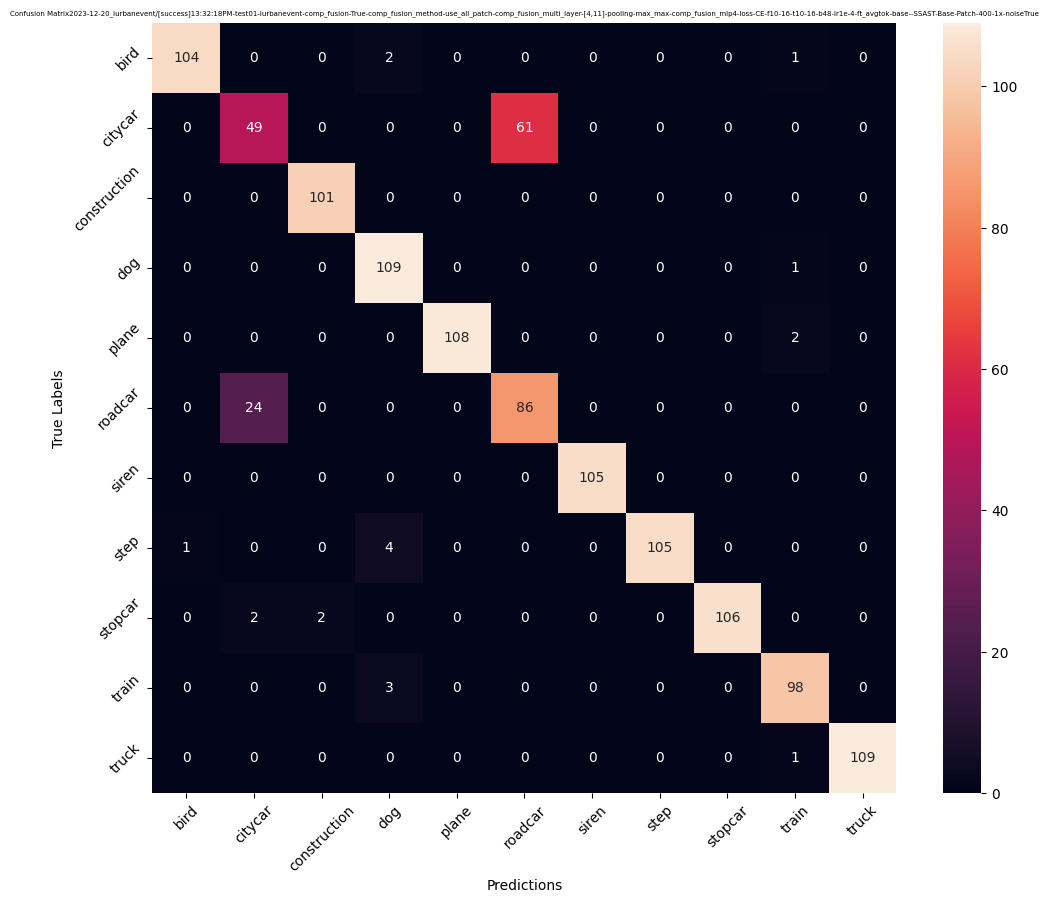

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
# print(pred_labels)
cm = confusion_matrix(test_labels,pred_labels)

df_cm = pd.DataFrame(cm, index = [i for i in labels_arr],
                columns = [i for i in labels_arr])

fig = plt.figure()
plt.figure(figsize = (12,10))
sn.heatmap(df_cm, annot=True, fmt='g') #[Hyosun] fmt='g' added to remove e from the count
plt.xticks(rotation=45)
plt.yticks(rotation=45)
plt.xlabel('Predictions')
plt.ylabel('True Labels')
plt.title('Confusion Matrix'+result_dir, fontdict={'fontsize': 5}, loc='center', )
# fig.savefig('confusion_matrix.jpg')

plt.savefig('IurbanEvent_conf_mat.png',dpi=300)



In [ ]:
best_epoch_1

21

In [ ]:
best_epoch_1+1 #[Hyosun] real best epoch

22

In [ ]:
results[best_epoch_1,0] #[Hyosun] real best acc

'9.121621621621621712e-01'

In [ ]:
        # if main_metrics == 'mAP':
        #     result[epoch-1, :] = [mAP, mAUC, average_precision, average_recall, d_prime(mAUC), loss_meter.avg, valid_loss, cum_mAP, cum_mAUC, optimizer.param_groups[0]['lr']]
        # else:
        #     result[epoch-1, :] = [acc, mAUC, average_precision, average_recall, d_prime(mAUC), loss_meter.avg, valid_loss, cum_acc, cum_mAUC, optimizer.param_groups[0]['lr']]
        # np.savetxt(exp_dir + '/result.csv', result, delimiter=',')
        # print('validation finished')

- result.csv에 들어가는 10 column들 순서:
    - [acc, mAUC, average_precision, average_recall, d_prime(mAUC), loss_meter.avg, valid_loss, cum_acc, cum_mAUC, optimizer.param_groups[0]['lr']]
